<a href="https://colab.research.google.com/github/sebastianvettel1212/GrokkingDeepLearning/blob/main/03_Forward_Propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 3 — *Forward Propagation*: Pengantar Prediksi Neural Network (*Introduction to Neural Prediction*)

**Buku:** *Grokking Deep Learning* — Andrew W. Trask (Manning, 2019)

Langkah pertama siklus belajar: ***predict***. Kita membangun neural network sederhana **dari nol** yang menghasilkan prediksi, dari 1 input–1 output hingga jaringan dengan *hidden layer*. Kode diambil dari repositori resmi buku, ditambah catatan teori.

---

## Daftar Isi
1. Neural Network 1 Input → 1 Output
2. Prediksi dengan Banyak Input (*Multiple Inputs*)
3. *Dot Product* sebagai Ukuran Kemiripan
4. Prediksi dengan Banyak Output (*Multiple Outputs*)
5. Banyak Input dan Banyak Output
6. Prediksi atas Prediksi (*Hidden Layer*)
7. Primer NumPy
8. Ringkasan Bab

---

## Pengantar
Jaringan yang dipakai berulang: data pertandingan sebuah tim (`toes` = rata-rata jumlah jari kaki, `wlrec` = persentase menang, `nfans` = jumlah penggemar dalam juta) dipakai untuk memprediksi hasil pertandingan. Dengan kata lain: **memetakan input yang diketahui menjadi prediksi**.

## 1. Neural Network 1 Input → 1 Output

Neural network paling sederhana: **satu input, satu bobot, satu output**.
$$\text{prediksi} = \text{input}\times\text{bobot}$$

**Bobot (*weight*)** adalah "kenop" yang mengatur seberapa sensitif prediksi terhadap input. Tiga cara memandang bobot:
1. Sebagai **pengali** input,
2. Sebagai **tingkat sensitivitas** (naik 1 pada input → prediksi naik sebesar bobot),
3. Sebagai **parameter** yang kelak dipelajari (Bab 4).

In [1]:
# The network:

weight = 0.1
def neural_network(input, weight):
    prediction = input * weight
    return prediction

# How we use the network to predict something:

number_of_toes = [8.5, 9.5, 10, 9]
input = number_of_toes[0]
pred = neural_network(input,weight)
print(pred)

0.8500000000000001


**Interpretasi:** $8{,}5\times0{,}1=0{,}85$. Prediksi (peluang menang) 85% dari input jumlah jari kaki 8,5.

---
## 2. Prediksi dengan Banyak Input (*Multiple Inputs*)

Bila ada beberapa input, setiap input punya bobot sendiri. Prediksi adalah **jumlah terbobot** (*weighted sum*):
$$\text{pred}=\sum_i x_i\,w_i = x_1w_1+x_2w_2+x_3w_3$$
Kontribusi tiap input = `input × bobot`; bobot 0 berarti input itu **diabaikan**.

### Kode Python murni

In [2]:
def w_sum(a,b):
    assert(len(a) == len(b))
    output = 0
    for i in range(len(a)):
        output += (a[i] * b[i])
    return output

weights = [0.1, 0.2, 0]

def neural_network(input, weights):
    pred = w_sum(input,weights)
    return pred

# This dataset is the current
# status at the beginning of
# each game for the first 4 games
# in a season.

# toes = current number of toes
# wlrec = current games won (percent)
# nfans = fan count (in millions)

toes =  [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

# Input corresponds to every entry
# for the first game of the season.

input = [toes[0],wlrec[0],nfans[0]]
pred = neural_network(input,weights)

print(pred)

0.9800000000000001


### Versi NumPy
`input.dot(weights)` melakukan *weighted sum* sekaligus.

In [3]:
import numpy as np
weights = np.array([0.1, 0.2, 0])
def neural_network(input, weights):
    pred = input.dot(weights)
    return pred

toes =  np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65, 0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])

# Input corresponds to every entry
# for the first game of the season.

input = np.array([toes[0],wlrec[0],nfans[0]])
pred = neural_network(input,weights)

print(pred)

0.9800000000000001


**Interpretasi:** $8{,}5\cdot0{,}1+0{,}65\cdot0{,}2+1{,}2\cdot0=0{,}98$. Kedua versi menghasilkan nilai sama; `nfans` tidak berpengaruh karena bobotnya 0.

{'toes': 0.85, 'wlrec': 0.13, 'nfans': 0.0} | total = 0.98


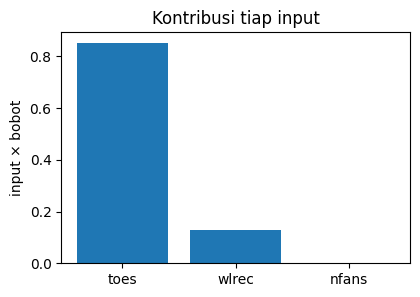

In [4]:
# Tambahan (tidak ada di buku): kontribusi tiap input terhadap prediksi
import matplotlib.pyplot as plt

nama = ['toes', 'wlrec', 'nfans']
kontribusi = input * weights
print({k: round(float(v), 3) for k, v in zip(nama, kontribusi)}, '| total =', round(float(kontribusi.sum()), 3))

plt.figure(figsize=(4.5, 3))
plt.bar(nama, kontribusi)
plt.ylabel('input × bobot')
plt.title('Kontribusi tiap input')
plt.show()

---
## 3. *Dot Product* sebagai Ukuran Kemiripan

*Weighted sum* sama dengan ***dot product*** vektor input dan bobot. Intuisinya: dot product mengukur **seberapa mirip** dua vektor.
- Bila input dan bobot **sama-sama besar pada posisi yang sama** → nilai besar (mirip, seperti operasi **AND** lunak).
- Bobot negatif berperan seperti **NOT** lunak (input besar mengurangi prediksi).
- Bobot 0 → input diabaikan.

Jadi bobot dapat dipandang sebagai **"template"** pola yang dicari jaringan pada input.

---
## 4. Prediksi dengan Banyak Output (*Multiple Outputs*)

Satu input dapat dipakai untuk memprediksi **beberapa hal sekaligus**. Setiap output punya bobot sendiri, dan input dikalikan ke tiap bobot (***elementwise multiplication***). Di sini kita memprediksi: *hurt?*, *win?*, *sad?* dari rekor menang-kalah saja.

In [5]:
# Instead of predicting just
# whether the team won or lost,
# now we're also predicting whether
# they are happy/sad AND the percentage
# of the team that is hurt. We are
# making this prediction using only
# the current win/loss record.

def ele_mul(number,vector):
    output = [0,0,0]
    assert(len(output) == len(vector))
    for i in range(len(vector)):
        output[i] = number * vector[i]
    return output

weights = [0.3, 0.2, 0.9]

def neural_network(input, weights):
    pred = ele_mul(input,weights)
    return pred

wlrec = [0.65, 0.8, 0.8, 0.9]
input = wlrec[0]
pred = neural_network(input,weights)

print(pred)

[0.195, 0.13, 0.5850000000000001]


**Interpretasi:** $0{,}65\times[0{,}3;0{,}2;0{,}9]=[0{,}195;0{,}13;0{,}585]$. Tiga prediksi independen dari satu input.

---
## 5. Banyak Input dan Banyak Output

Gabungan keduanya: tiap output dihitung dari seluruh input. Bobot disusun sebagai **matriks** (satu baris per output). Operasinya ***vector–matrix multiplication***: setiap baris matriks di-*dot product*-kan dengan vektor input.

In [6]:
            #toes %win #fans
weights = [ [0.1, 0.1, -0.3], #hurt?
            [0.1, 0.2, 0.0], #win?
            [0.0, 1.3, 0.1] ] #sad?

def w_sum(a,b):
    assert(len(a) == len(b))
    output = 0
    for i in range(len(a)):
        output += (a[i] * b[i])
    return output

def vect_mat_mul(vect,matrix):
    assert(len(vect) == len(matrix))
    output = [0,0,0]
    for i in range(len(vect)):
        output[i] = w_sum(vect,matrix[i])
    return output

def neural_network(input, weights):
    pred = vect_mat_mul(input,weights)
    return pred

# This dataset is the current
# status at the beginning of
# each game for the first 4 games
# in a season.

# toes = current number of toes
# wlrec = current games won (percent)
# nfans = fan count (in millions)

toes =  [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65,0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

# Input corresponds to every entry
# for the first game of the season.

input = [toes[0],wlrec[0],nfans[0]]
pred = neural_network(input,weights)

print(pred)

[0.555, 0.9800000000000001, 0.9650000000000001]


**Interpretasi:** keluaran `[hurt, win, sad]` ≈ `[0,555; 0,98; 0,965]`. Tiga prediksi dihitung dari tiga input memakai satu matriks bobot 3×3.

---
## 6. Prediksi atas Prediksi (*Hidden Layer*)

Jaringan dapat **ditumpuk**: output sebuah layer menjadi input layer berikutnya. Layer di antara input dan output disebut ***hidden layer***. Pada contoh ini: 3 input → 3 *hidden node* → 3 output.
$$\text{hid}=\text{input}\cdot W_{ih},\qquad \text{pred}=\text{hid}\cdot W_{hp}$$

In [7]:
            #toes %win #fans
ih_wgt = [ [0.1, 0.2, -0.1], #hid[0]
           [-0.1,0.1, 0.9], #hid[1]
           [0.1, 0.4, 0.1] ] #hid[2]

           #hid[0] hid[1] hid[2]
hp_wgt = [ [0.3, 1.1, -0.3], #hurt?
           [0.1, 0.2, 0.0], #win?
           [0.0, 1.3, 0.1] ] #sad?

weights = [ih_wgt, hp_wgt]

def neural_network(input, weights):
    hid = vect_mat_mul(input,weights[0])
    pred = vect_mat_mul(hid,weights[1])
    return pred

toes =  [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65,0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

# Input corresponds to every entry
# for the first game of the season.

input = [toes[0],wlrec[0],nfans[0]]
pred = neural_network(input,weights)

print(pred)

[0.21350000000000002, 0.14500000000000002, 0.5065]


### Versi NumPy

In [8]:
import numpy as np

#toes %win #fans
ih_wgt = np.array([
            [0.1, 0.2, -0.1], #hid[0]
            [-0.1,0.1, 0.9], #hid[1]
            [0.1, 0.4, 0.1]]).T #hid[2]


# hid[0] hid[1] hid[2]
hp_wgt = np.array([
            [0.3, 1.1, -0.3], #hurt?
            [0.1, 0.2, 0.0], #win?
            [0.0, 1.3, 0.1] ]).T #sad?

weights = [ih_wgt, hp_wgt]

def neural_network(input, weights):

    hid = input.dot(weights[0])
    pred = hid.dot(weights[1])
    return pred


toes =  np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65,0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])

input = np.array([toes[0],wlrec[0],nfans[0]])

pred = neural_network(input,weights)
print(pred)

[0.2135 0.145  0.5065]


**Interpretasi:** versi Python murni dan NumPy menghasilkan prediksi yang sama (≈ `[0,2135; 0,145; 0,5065]`). Bobot di NumPy ditransposisi (`.T`) agar `input.dot(weights)` sesuai susunan baris/kolom.

> **Catatan teori:** dua layer **linear** yang ditumpuk setara dengan satu layer linear (perkalian dua matriks = satu matriks). Kekuatan *hidden layer* baru muncul bersama **nonlinearitas** (Bab 6).

---
## 7. Primer NumPy

NumPy menyediakan vektor, matriks, dan operasi pada keduanya.

In [9]:
import numpy as np

a = np.array([0,1,2,3]) # a vector
b = np.array([4,5,6,7]) # another vector
c = np.array([[0,1,2,3], # a matrix
              [4,5,6,7]])

d = np.zeros((2,4)) # (2x4 matrix of zeros)
e = np.random.rand(2,5) # random 2x5
# matrix with all numbers between 0 and 1

print(a)
print(b)
print(c)
print(d)
print(e)

[0 1 2 3]
[4 5 6 7]
[[0 1 2 3]
 [4 5 6 7]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0.17725628 0.43183743 0.04081174 0.25160563 0.14814212]
 [0.32623251 0.82054944 0.05554089 0.02353849 0.92553632]]


### Broadcasting dan operasi elementwise
Kode buku sengaja menyertakan satu operasi yang gagal (`a * e`); di sini dibungkus `try/except` agar notebook tetap berjalan sambil memperlihatkan pesan galatnya.

In [10]:
print(a * 0.1) # multiplies every number in vector "a" by 0.1

print(c * 0.2) # multiplies every number in matrix "c" by 0.2

print(a * b) # multiplies elementwise between a and b (columns paired up)

print(a * b * 0.2) # elementwise multiplication then multiplied by 0.2

print(a * c) # since c has the same number of columns as a, this performs
# elementwise multiplication on every row of the matrix "c"

try:
    print(a * e) # since a and e don't have the same number of columns, this
    # throws a "Value Error: operands could not be broadcast together with.."
except ValueError as err:
    print('ValueError:', err)

[0.  0.1 0.2 0.3]
[[0.  0.2 0.4 0.6]
 [0.8 1.  1.2 1.4]]
[ 0  5 12 21]
[0.  1.  2.4 4.2]
[[ 0  1  4  9]
 [ 0  5 12 21]]
ValueError: operands could not be broadcast together with shapes (4,) (2,5) 


### Aturan *shape* pada `dot`
Untuk matriks, `(m, n) · (n, k) → (m, k)`: jumlah **kolom** matriks pertama harus sama dengan jumlah **baris** matriks kedua.

In [11]:
a = np.zeros((1,4)) # vector of length 4
b = np.zeros((4,3)) # matrix with 4 rows & 3 columns

c = a.dot(b)
print(c.shape)

(1, 3)


In [12]:
a = np.zeros((2,4)) # matrix with 2 rows and 4 columns
b = np.zeros((4,3)) # matrix with 4 rows & 3 columns

c = a.dot(b)
print(c.shape) # outputs (2,3)

e = np.zeros((2,1)) # matrix with 2 rows and 1 columns
f = np.zeros((1,3)) # matrix with 1 row & 3 columns

g = e.dot(f)
print(g.shape) # outputs (2,3)

h = np.zeros((5,4)).T # matrix with 4 rows and 5 columns
i = np.zeros((5,6)) # matrix with 6 rows & 5 columns
j = h.dot(i)
print(j.shape) # outputs (4,6)

h = np.zeros((5,4)) # matrix with 5 rows and 4 columns
i = np.zeros((5,6)) # matrix with 5 rows & 6 columns
try:
    j = h.dot(i)
    print(j.shape)
except ValueError as err:
    print('ValueError (shape tidak cocok):', err)

(2, 3)
(2, 3)
(4, 6)
ValueError (shape tidak cocok): shapes (5,4) and (5,6) not aligned: 4 (dim 1) != 5 (dim 0)


**Interpretasi:** tiga `dot` pertama valid dan menghasilkan shape `(1,3)`, `(2,3)`, `(2,3)`, `(4,6)`. Yang terakhir gagal karena `(5,4)·(5,6)` melanggar aturan `n` harus sama.

---
## 8. Ringkasan Bab

- ***Forward propagation*** = mengalirkan input melalui bobot untuk menghasilkan prediksi.
- ***Dot product*** mengukur **kemiripan** input dengan bobot; kontribusi = input × bobot.
- Neural network dapat memiliki banyak input, banyak output, dan **ditumpuk** (*hidden layer*); perhatikan aturan *shape* `(m,n)·(n,k) → (m,k)`.

### Rangkuman konsep
| Subbab | Konsep | Kode |
|---|---|---|
| 1 input → 1 output | pred = input × bobot | `neural_network(input, weight)` |
| Banyak input | *weighted sum* | `w_sum`, `input.dot(weights)` |
| Banyak output | *elementwise multiplication* | `ele_mul` |
| Banyak input & output | *vector–matrix multiplication* | `vect_mat_mul` |
| *Hidden layer* | Prediksi atas prediksi | `hid = input.dot(W1)`, `pred = hid.dot(W2)` |
| NumPy | Broadcasting, aturan *shape* | `np.zeros`, `.dot`, `.T` |